In [122]:
import cv2
import numpy as np
from ultralytics import YOLO

class NumberClassifier:
    def __init__(self, model_path="yolov8n-cls.pt", conf_threshold=0.1, device="auto"):
        """
        数字分类器初始化
        :param model_path: 预训练模型路径（支持.pt或.onnx格式）
        :param conf_threshold: 置信度阈值（低于此值视为无效预测）
        :param device: 推理设备（'cpu', 'cuda' 或 'auto'自动选择）
        """
        # 加载模型并强制转换为float32精度[6](@ref)
        self.model = YOLO(model_path).float() if device == "cpu" else YOLO(model_path)
        self.conf_threshold = conf_threshold
        self.device = device
        self.class_names = {i: str(i) for i in range(10)}  # 数字0-9的类别映射

    def detect(self, image):
        """
        执行数字分类推理
        :param image: 输入图像 (支持文件路径或numpy数组)
        :return: (predicted_digit, confidence) 元组 (若无有效预测返回None)
        """
        # 支持文件路径输入[5](@ref)
        if isinstance(image, str):
            image = cv2.imread(image)
            if image is None:
                raise ValueError(f"无法读取图像: {image}")
        
        if len(image.shape) == 3 and image.shape[2] == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        results = self.model(image, verbose=False)

      # 后处理 - 提取概率最高的类别
        if results and hasattr(results[0], "probs"):
            probs = results[0].probs.data.cpu().numpy()
            top1_index = np.argmax(probs)
            confidence = probs[top1_index]

            if confidence >= self.conf_threshold:
                result = int(self.class_names[top1_index]), float(confidence)
                number = result[0]
                return number
        return None

# # 使用示例
# if __name__ == "__main__":
#     # 初始化分类器
#     number_classifier = NumberClassifier(model_path="../workdir/ros2_ws/model/number.pt")
    
#     # 示例1：处理图像文件
#     result = number_classifier.detect("test_image.jpg")
#     print(f"识别结果: {result}")
    
#     # 示例2：处理摄像头帧
#     cap = cv2.VideoCapture(0)
#     while True:
#         ret, frame = cap.read()
#         if not ret: break
            
#         # 执行分类
#         result = number_classifier.detect(frame)
        
#         # 可视化结果
#         vis_frame = number_classifier.visualize(frame, result)
#         cv2.imshow("Digit Classification", vis_frame)
        
#         if cv2.waitKey(1) == 27:  # ESC退出
#             break

In [123]:
frame = cv2.imread('../assets/test_number.jpg')

In [124]:
from matplotlib import pyplot as plt
%matplotlib inline


def show_image(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

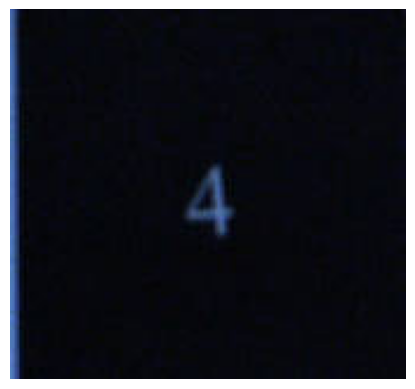

In [125]:
show_image(frame)

In [126]:
number_classifier = NumberClassifier(model_path="../workdir/ros2_ws/model/number.pt")

In [127]:
result = number_classifier.detect(frame)

In [128]:
print(result)

1
